In [8]:
SLICE_NAME = 'qfabric-bb84-2'
SCENARIO   = 'validation/scenarios/fabric_1km.yml'

In [9]:
import os, sys, json
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR)); sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
import deploy_fabric_modified as df

fablib = df.get_fablib()
slice_obj = fablib.get_slice(name=SLICE_NAME)
slice_obj.show()

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
CEPH Manager,https://ceph-mgr.fabric-testbed.net
Token File,/home/fabric/work/fabric_config/id_token.json
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
Bastion Host,bastion.fabric-testbed.net
Bastion Username,audreyf_0000527467
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub


User: audreyf@illinois.edu bastion key is valid!
Configuration is valid


ID,d8ea8804-1e65-4186-a902-d6006de32667
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-08-04 21:27:56 +0000
Lease Start (UTC),2026-07-20 21:27:56 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


ID,d8ea8804-1e65-4186-a902-d6006de32667
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-08-04 21:27:56 +0000
Lease Start (UTC),2026-07-20 21:27:56 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


In [ ]:
#BASELINE RUNS

import json
import pandas as pd
import deploy_fabric_modified as deploy

# run 10 baseline conditions
conditions = [{'name': f'baseline_run_{i}'} for i in range(1, 11)]

rows = deploy.run_network_conditions_experiment(
    slice_obj,
    SCENARIO,
    conditions=conditions
)

# save to json
with open('/home/fabric/work/qkd-pqc-dependability/results/baseline_results.json', 'w') as f:
    json.dump(rows, f, indent=2)

# save to csv
df_baseline = pd.DataFrame(rows)
df_baseline.to_csv('/home/fabric/work/qkd-pqc-dependability/results/baseline_results.csv', index=False)

print(f"Completed {len(rows)} baseline runs")
print(df_baseline[['qber', 'key_bits_per_sec', 'elapsed_seconds']].describe())

In [15]:
#SINGLE PARAMETER SWEEPS

import json
import pandas as pd
import deploy_fabric_modified as deploy

rows = deploy.run_single_axis_sweeps(
    slice_obj,
    scenario_path="validation/scenarios/fabric_1km.yml",
    n_runs=5,
    port=5100,
    save_json=True,
)

df_baseline = pd.DataFrame(rows)
df_baseline.to_csv('/home/fabric/work/qkd-pqc-dependability/results/single_axis_sweeps.csv', index=False)
print(f"Completed {len(rows)} single axis runs")


##### axis=latency_ms value=1 (run 1/5) #####
  cleared classical netem on Alice and Bob

=== Applying classical-channel netem (TCP:5100) ===
  alice (enp7s0): netem delay 1ms
  bob (enp7s0): netem delay 1ms

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 10000 photons on enp7s0
Alice: Finished sending 10000 photons
Alice: Connecting to Bob at 10.10.1.2:5100
  Retrying connection to 10.10.1.2:5100 (attempt 2/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 3/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 4/60)...
  Retrying connection to 10.10.1.2:5100 (attempt 5/60)...
  Retrying connection to 10.

In [17]:
def is_success(rows, qber_threshold=0.11, key_rate_floor=1.0):
    """Label each row success/fail per F: {QBER >= 11% OR KeyRate -> 0}.
    key_rate_floor is a placeholder for "approaches 0" — confirm with Dr. Cao.
    Rows with no measurement (prior 'error' field) are marked fail, not success.
    """
    for row in rows:
        if row.get("error"):
            row["success"] = False
            row["fail_reason"] = row["error"]
            continue

        qber = row.get("qber")
        key_rate = row.get("key_bits_per_sec")

        if qber is None or key_rate is None:
            row["success"] = False
            row["fail_reason"] = "missing qber or key_bits_per_sec"
            continue

        qber_fail = qber >= qber_threshold
        rate_fail = key_rate < key_rate_floor

        row["success"] = not (qber_fail or rate_fail)
        if qber_fail and rate_fail:
            row["fail_reason"] = "qber_and_rate"
        elif qber_fail:
            row["fail_reason"] = "qber"
        elif rate_fail:
            row["fail_reason"] = "key_rate"
        else:
            row["fail_reason"] = None

    return rows

In [21]:
rows = is_success(rows)
df_baseline = pd.DataFrame(rows)
df_baseline.to_csv('/home/fabric/work/qkd-pqc-dependability/results/single_axis_sweeps.csv', index=False)
print(df_baseline['success'].value_counts())

success
True     203
False      2
Name: count, dtype: int64


In [24]:
prob_success = df_baseline['success'].value_counts()/df_baseline.shape[0]
print(prob_success)

success
True     0.990244
False    0.009756
Name: count, dtype: float64


In [29]:
summary = (df_baseline.rename(columns={'axis': 'sweep_axis'})
           .groupby(['sweep_axis', 'value'])
           .agg(
               qber_mean=('qber', 'mean'),
               qber_std=('qber', 'std'),
               key_rate_mean=('key_bits_per_sec', 'mean'),
               key_rate_std=('key_bits_per_sec', 'std'),
               final_key_bits_mean=('final_key_bits', 'mean'),
               final_key_bits_std=('final_key_bits', 'std'),
               success_prob=('success', 'mean'),
               n=('success', 'size'),
           )
           .reset_index()
           .rename(columns={'sweep_axis': 'axis'}))

In [ ]:
print(summary)
summary.to_csv('/home/fabric/work/qkd-pqc-dependability/results/single_axis_sweep_summary.csv', index=False)

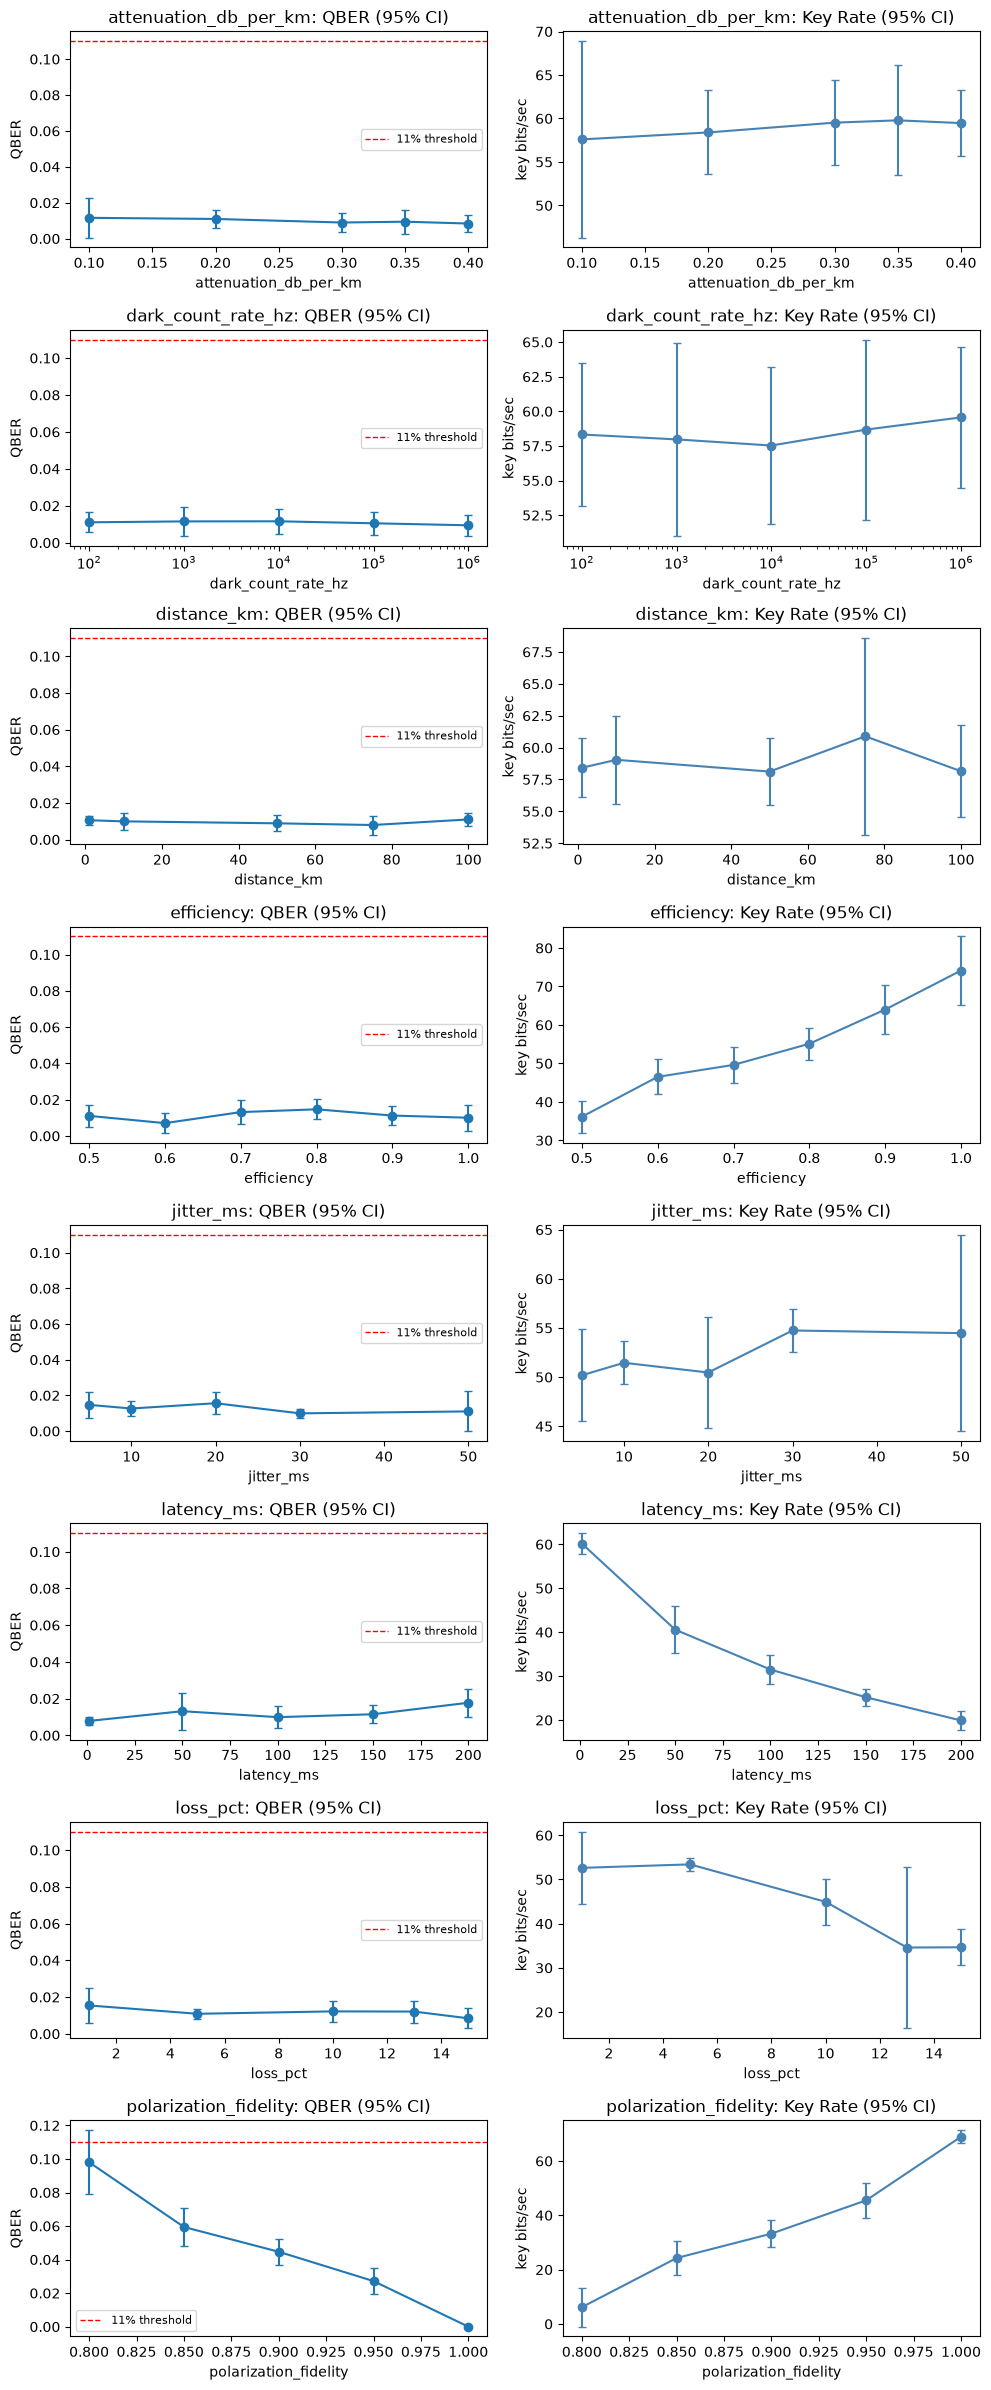

In [36]:
import matplotlib.pyplot as plt
from scipy import stats

axes_list = summary['axis'].unique()
n_axes = len(axes_list)

fig, axs = plt.subplots(n_axes, 2, figsize=(10, 3 * n_axes))

for i, axis_name in enumerate(axes_list):
    d = summary[summary['axis'] == axis_name].sort_values('value').copy()

    # 95% CI via t-distribution, using per-point n (falls back safely if any point has n=1)
    t_crit = d['n'].apply(lambda n: stats.t.ppf(0.975, n - 1) if n > 1 else 0)
    qber_ci = t_crit * d['qber_std'] / d['n']**0.5
    rate_ci = t_crit * d['key_rate_std'] / d['n']**0.5

    axs[i, 0].errorbar(d['value'], d['qber_mean'], yerr=qber_ci, marker='o', capsize=3)
    axs[i, 0].set_title(f'{axis_name}: QBER (95% CI)')
    axs[i, 0].set_xlabel(axis_name)
    axs[i, 0].set_ylabel('QBER')
    axs[i, 0].axhline(0.11, color='red', linestyle='--', linewidth=1, label='11% threshold')
    axs[i, 0].legend(fontsize=8)

    axs[i, 1].errorbar(d['value'], d['key_rate_mean'], yerr=rate_ci, marker='o', capsize=3, color='steelblue')
    axs[i, 1].set_title(f'{axis_name}: Key Rate (95% CI)')
    axs[i, 1].set_xlabel(axis_name)
    axs[i, 1].set_ylabel('key bits/sec')

    if axis_name == 'dark_count_rate_hz':
        axs[i, 0].set_xscale('log')
        axs[i, 1].set_xscale('log')

plt.tight_layout()
plt.savefig('/home/fabric/work/qkd-pqc-dependability/results/single_axis_sweeps_plot.png', dpi=150)
plt.show()

In [37]:
def fit_linear_regression(summary_df, axis_name, y_col='qber_mean'):
    """Fit OLS linear regression of y_col vs value, for one sweep axis.

    Returns dict with slope, intercept, r_squared, p_value, std_err, and the
    fitted x/y arrays for plotting. y_col should be one of the *_mean columns
    in your summary dataframe (e.g. 'qber_mean', 'key_rate_mean').
    """
    from scipy import stats
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        raise ValueError(f"Not enough valid points to fit regression for axis={axis_name}, y_col={y_col} (n={len(x)})")

    result = stats.linregress(x, y)

    return {
        "axis": axis_name,
        "y_col": y_col,
        "slope": result.slope,
        "intercept": result.intercept,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "std_err": result.stderr,
        "x": x,
        "y_fit": result.intercept + result.slope * x,
        "n_points": len(x),
    }

In [42]:
def fit_quadratic_regression(summary_df, axis_name, y_col='qber_mean'):
    """Fit y = a*x^2 + b*x + c via least squares, for one sweep axis."""
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        raise ValueError(f"Need >=3 points for quadratic fit (axis={axis_name}, y_col={y_col}, n={len(x)})")

    coeffs = np.polyfit(x, y, 2)  # [a, b, c]
    y_fit = np.polyval(coeffs, x)

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    return {
        "axis": axis_name, "y_col": y_col,
        "a": coeffs[0], "b": coeffs[1], "c": coeffs[2],
        "r_squared": r_squared,
        "x": x, "y_fit": y_fit, "n_points": len(x),
    }


def fit_exponential_regression(summary_df, axis_name, y_col='qber_mean'):
    """Fit y = a * exp(b*x) via log-linearization (log(y) = log(a) + b*x).
    Requires all y > 0 — drops non-positive points with a warning since log
    is undefined there.
    """
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y) & (y > 0)
    n_dropped = np.sum(~np.isnan(y)) - np.sum(mask)
    if n_dropped > 0:
        print(f"  (exp fit {axis_name}/{y_col}: dropped {n_dropped} non-positive/NaN points)")
    x, y = x[mask], y[mask]

    if len(x) < 2:
        raise ValueError(f"Not enough positive points for exponential fit (axis={axis_name}, y_col={y_col}, n={len(x)})")

    log_y = np.log(y)
    b, log_a = np.polyfit(x, log_y, 1)
    a = np.exp(log_a)
    y_fit = a * np.exp(b * x)

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    return {
        "axis": axis_name, "y_col": y_col,
        "a": a, "b": b,
        "r_squared": r_squared,
        "x": x, "y_fit": y_fit, "n_points": len(x),
    }

In [44]:
def fit_exponential_regression_log_x(summary_df, axis_name, y_col='qber_mean'):
    """Same as fit_exponential_regression, but regresses against log10(value)
    instead of raw value. Use for axes swept multiplicatively/log-spaced
    (e.g. dark_count_rate_hz spanning 100 to 1e6).
    """
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x_raw = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y) & (y > 0) & (x_raw > 0)
    n_dropped = np.sum(~np.isnan(y)) - np.sum(mask)
    if n_dropped > 0:
        print(f"  (exp-logx fit {axis_name}/{y_col}: dropped {n_dropped} non-positive/NaN points)")
    x_raw, y = x_raw[mask], y[mask]

    if len(x_raw) < 2:
        raise ValueError(f"Not enough positive points for exp-logx fit (axis={axis_name}, y_col={y_col}, n={len(x_raw)})")

    x = np.log10(x_raw)
    log_y = np.log(y)
    b, log_a = np.polyfit(x, log_y, 1)
    a = np.exp(log_a)
    y_fit = a * np.exp(b * x)

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    return {
        "axis": axis_name, "y_col": y_col,
        "a": a, "b": b,
        "r_squared": r_squared,
        "x": x_raw, "x_log": x, "y_fit": y_fit, "n_points": len(x_raw),
    }


def fit_quadratic_regression_log_x(summary_df, axis_name, y_col='qber_mean'):
    """Same as fit_quadratic_regression, but fits y = a*log10(x)^2 + b*log10(x) + c."""
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x_raw = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y) & (x_raw > 0)
    x_raw, y = x_raw[mask], y[mask]

    if len(x_raw) < 3:
        raise ValueError(f"Need >=3 points for quad-logx fit (axis={axis_name}, y_col={y_col}, n={len(x_raw)})")

    x = np.log10(x_raw)
    coeffs = np.polyfit(x, y, 2)
    y_fit = np.polyval(coeffs, x)

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    return {
        "axis": axis_name, "y_col": y_col,
        "a": coeffs[0], "b": coeffs[1], "c": coeffs[2],
        "r_squared": r_squared,
        "x": x_raw, "x_log": x, "y_fit": y_fit, "n_points": len(x_raw),
    }

In [55]:
def spearman_correlation(summary_df, axis_name, y_col='qber_mean'):
    """Spearman rank correlation between axis value and y_col, for one axis.
    Use when the relationship might be monotonic but not linear — doesn't
    assume any particular functional form (unlike the regression fits).
    """
    from scipy import stats
    import numpy as np

    d = summary_df[summary_df['axis'] == axis_name].sort_values('value')
    x = d['value'].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        raise ValueError(f"Need >=3 points for Spearman (axis={axis_name}, y_col={y_col}, n={len(x)})")

    rho, p_value = stats.spearmanr(x, y)

    return {
        "axis": axis_name, "y_col": y_col,
        "rho": rho, "p_value": p_value, "n_points": len(x),
    }


def one_way_anova(raw_df, axis_name, y_col='qber', group_col='value'):
    """One-way ANOVA testing whether y_col's mean differs across the levels
    (values) of one sweep axis, using the raw per-run data (not the
    aggregated summary — ANOVA needs the individual run values per group,
    not pre-averaged ones).
    """
    from scipy import stats
    import numpy as np

    d = raw_df[raw_df['axis'] == axis_name] if 'axis' in raw_df.columns else raw_df[raw_df['sweep_axis'] == axis_name]

    groups = [
        g[y_col].dropna().to_numpy(dtype=float)
        for _, g in d.groupby(group_col)
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        raise ValueError(f"Need >=2 groups with data for ANOVA (axis={axis_name}, y_col={y_col})")

    f_stat, p_value = stats.f_oneway(*groups)

    return {
        "axis": axis_name, "y_col": y_col,
        "f_stat": f_stat, "p_value": p_value,
        "n_groups": len(groups),
        "group_sizes": [len(g) for g in groups],
    }

In [57]:
def levene_test(raw_df, axis_name, y_col='qber', group_col='value'):
    """Levene's test for homogeneity of variance across levels of one axis.
    Run this before trusting an ANOVA result — ANOVA assumes equal variance
    across groups; if Levene's p < 0.05, that assumption is violated and the
    ANOVA p-value is less trustworthy (consider Welch's ANOVA or Kruskal-Wallis
    instead, which don't require it).
    """
    from scipy import stats
    import numpy as np

    d = raw_df[raw_df['axis'] == axis_name] if 'axis' in raw_df.columns else raw_df[raw_df['sweep_axis'] == axis_name]

    groups = [
        g[y_col].dropna().to_numpy(dtype=float)
        for _, g in d.groupby(group_col)
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        raise ValueError(f"Need >=2 groups with data for Levene's test (axis={axis_name}, y_col={y_col})")

    stat, p_value = stats.levene(*groups)

    return {
        "axis": axis_name, "y_col": y_col,
        "levene_stat": stat, "p_value": p_value,
        "n_groups": len(groups),
        "group_sizes": [len(g) for g in groups],
    }

In [ ]:
for axis in axis_names:
    print(f"\n===== {axis} =====")
    for y_summary, y_raw in [('key_rate_mean', 'key_bits_per_sec'), ('qber_mean', 'qber')]:
        print(f"  -- {y_raw} --")
        try:
            lin = fit_linear_regression(summary, axis, y_col=y_summary)
            print(f"  linear:   slope={lin['slope']:.5f}, R²={lin['r_squared']:.3f}, p={lin['p_value']:.4f}")
        except ValueError as e:
            print(f"  linear:   skipped ({e})")
        try:
            if axis == 'dark_count_rate_hz':
                quad = fit_quadratic_regression_log_x(summary, axis, y_col=y_summary)
            else:
                quad = fit_quadratic_regression(summary, axis, y_col=y_summary)
            print(f"  quad:     a={quad['a']:.5f}, b={quad['b']:.5f}, c={quad['c']:.5f}, R²={quad['r_squared']:.3f}")
        except ValueError as e:
            print(f"  quad:     skipped ({e})")
        try:
            if axis == 'dark_count_rate_hz':
                exp = fit_exponential_regression_log_x(summary, axis, y_col=y_summary)
            else:
                exp = fit_exponential_regression(summary, axis, y_col=y_summary)
            print(f"  exp:      a={exp['a']:.5f}, b={exp['b']:.5f}, R²={exp['r_squared']:.3f}")
        except ValueError as e:
            print(f"  exp:      skipped ({e})")
        try:
            spear = spearman_correlation(summary, axis, y_col=y_summary)
            print(f"  spearman: rho={spear['rho']:.3f}, p={spear['p_value']:.4f}")
        except ValueError as e:
            print(f"  spearman: skipped ({e})")
        try:
            anova = one_way_anova(df_baseline, axis, y_col=y_raw)
            print(f"  anova:    F={anova['f_stat']:.3f}, p={anova['p_value']:.4f}, groups={anova['group_sizes']}")
        except ValueError as e:
            print(f"  anova:    skipped ({e})")
        try:
            lev = levene_test(df_baseline, axis, y_col=y_raw)
            print(f"  levene:   stat={lev['levene_stat']:.3f}, p={lev['p_value']:.4f}")
        except ValueError as e:
            print(f"  levene:   skipped ({e})")

In [61]:
def standardized_coefficients(summary_df, axis_names, y_col):
    """Standardized (beta) linear regression coefficients across multiple axes,
    so their coefficients are comparable despite different units/scales
    (e.g. loss_pct in % vs distance_km in km).

    Standardizes x and y (z-score) per axis, then fits linear regression —
    the resulting slope is the standardized beta: how many std devs y changes
    per 1 std dev change in x. Returns a list of dicts sorted by |beta|
    descending, so the most impactful axis (in relative terms) is first.
    """
    from scipy import stats
    import numpy as np

    results = []
    for axis in axis_names:
        d = summary_df[summary_df['axis'] == axis].sort_values('value')
        x = d['value'].to_numpy(dtype=float)
        y = d[y_col].to_numpy(dtype=float)

        mask = ~np.isnan(y)
        x, y = x[mask], y[mask]

        if len(x) < 2:
            results.append({"axis": axis, "y_col": y_col, "beta": None,
                             "r_squared": None, "p_value": None,
                             "note": f"skipped (n={len(x)})"})
            continue

        x_std, y_std = np.std(x), np.std(y)
        if x_std == 0 or y_std == 0:
            results.append({"axis": axis, "y_col": y_col, "beta": None,
                             "r_squared": None, "p_value": None,
                             "note": "skipped (zero variance in x or y)"})
            continue

        x_z = (x - np.mean(x)) / x_std
        y_z = (y - np.mean(y)) / y_std

        fit = stats.linregress(x_z, y_z)

        results.append({
            "axis": axis, "y_col": y_col,
            "beta": fit.slope,           # standardized coefficient
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
            "n_points": len(x),
            "note": None,
        })

    results.sort(key=lambda r: abs(r["beta"]) if r["beta"] is not None else -1, reverse=True)
    return results

In [ ]:
beta_key_rate = standardized_coefficients(summary, axis_names, y_col='key_rate_mean')
beta_qber = standardized_coefficients(summary, axis_names, y_col='qber_mean')

for r in beta_key_rate:
    if r["beta"] is not None:
        print(f"{r['axis']:25s} beta={r['beta']:+.3f}  R²={r['r_squared']:.3f}  p={r['p_value']:.4f}")
    else:
        print(f"{r['axis']:25s} {r['note']}")

In [73]:
def quadratic_vs_linear_test(raw_df, x_col, y_col):
    """
    Nested F-test comparing linear vs quadratic regression.

    H0: quadratic term is unnecessary (linear model is sufficient)
    H1: quadratic term significantly improves the fit

    If p < 0.05, quadratic regression is a meaningful improvement.
    """
    import numpy as np
    import statsmodels.api as sm
    from statsmodels.stats.anova import anova_lm

    d = summary[[x_col, y_col]].dropna()

    x = d[x_col].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    if len(x) < 4:
        raise ValueError("Need at least 4 points for model comparison")

    # Linear model: y = b0 + b1*x
    X_linear = sm.add_constant(x)
    linear_model = sm.OLS(y, X_linear).fit()

    # Quadratic model: y = b0 + b1*x + b2*x^2
    X_quad = np.column_stack([x, x**2])
    X_quad = sm.add_constant(X_quad)
    quad_model = sm.OLS(y, X_quad).fit()

    # Nested F-test
    comparison = anova_lm(linear_model, quad_model)

    return {
        "x_col": x_col,
        "y_col": y_col,
        "linear_R2": linear_model.rsquared,
        "linear_adj_R2": linear_model.rsquared_adj,
        "quad_R2": quad_model.rsquared,
        "quad_adj_R2": quad_model.rsquared_adj,
        "quadratic_coef": quad_model.params[2],
        "quadratic_p_value": quad_model.pvalues[2],
        "F_stat": comparison.iloc[1]["F"],
        "F_p_value": comparison.iloc[1]["Pr(>F)"],
        "quadratic_better": comparison.iloc[1]["Pr(>F)"] < 0.05,
        "n": len(x)
    }

In [ ]:
axes = [
    "latency_ms",
    "jitter_ms",
    "loss_pct",
    "attenuation_db_per_km",
    "distance_km",
    "polarization_fidelity",
    "dark_count_rate_hz",
    "efficiency"
]

for axis in axes:
    r = quadratic_vs_linear_test(
        summary,
        x_col="value",
        y_col="key_rate_mean"
    )

    print(
        axis,
        "quad better:", r["quadratic_better"],
        "p =", r["F_p_value"]
    )

for axis in axes:
    r = quadratic_vs_linear_test(
        df_baseline,
        x_col="value",
        y_col="qber_mean"
    )

    print(
        axis,
        "quad better:", r["quadratic_better"],
        "p =", r["F_p_value"]
    )

In [89]:
pf_vals = [0.8, 0.9, 1.0]
eff_vals = [0.5, 0.8, 1.0]
loss_vals = [1, 10, 15]
latency_vals = [1, 100, 200]

joint_results = {}
joint_results['pf_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'efficiency', pf_vals, eff_vals)
joint_results['pf_x_loss']       = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'loss_pct', pf_vals, loss_vals)
joint_results['pf_x_latency']    = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'latency_ms', pf_vals, latency_vals)
joint_results['loss_x_efficiency']    = deploy.run_joint_axis_sweep(slice_obj, 'loss_pct', 'efficiency', loss_vals, eff_vals)
joint_results['latency_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'latency_ms', 'efficiency', latency_vals, eff_vals)

  cleared classical netem on Alice and Bob

=== Configuring switch (threshold=193305371) ===
  Switch interfaces: enp8s0 (Alice), enp7s0 (Bob)
  Alice MAC: 0E:A9:B5:58:70:AB
  Bob MAC:   02:49:B1:09:C5:4F
  Switch Alice-side MAC: 1A:9E:9B:43:74:D7
  Switch Bob-side MAC:   16:E2:21:CF:C2:97
  Compiling P4 program...
  Starting BMv2...
  Configuring tables...
  Switch configured and running

##### polarization_fidelity=0.8, efficiency=0.5 (run 1/3) #####

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 10000 photons on enp7s0
Alice: Finished sending 10000 photons
Alice: Connecting to Bob at 10.10.1.2:5100
  Retrying c

KeyboardInterrupt: 

In [96]:
import json
import shutil
from pathlib import Path

results_dir = Path('/home/fabric/work/qkd-pqc-dependability/results')
src = results_dir / 'joint_polarization_fidelity_x_loss_pct.json'

with open(src) as f:
    pf_x_loss_data = json.load(f)

print(f"Rows saved so far: {len(pf_x_loss_data)}")
print(f"Last completed combo: {pf_x_loss_data[-1] if pf_x_loss_data else 'none'}")

# make a timestamped backup copy so nothing later can overwrite/corrupt it
import time
backup_path = results_dir / f"joint_pf_x_loss_BACKUP_{int(time.time())}.json"
shutil.copy(src, backup_path)
print(f"Backup saved -> {backup_path}")

results_dir = Path('/home/fabric/work/qkd-pqc-dependability/results')
src = results_dir / 'joint_polarization_fidelity_x_efficiency.json'

with open(src) as f:
    pf_x_efficiency_data = json.load(f)

print(f"Rows saved so far: {len(pf_x_efficiency_data)}")
print(f"Last completed combo: {pf_x_efficiency_data[-1] if pf_x_efficiency_data else 'none'}")

# make a timestamped backup copy so nothing later can overwrite/corrupt it
import time
backup_path = results_dir / f"pf_x_efficiency_data_BACKUP_{int(time.time())}.json"
shutil.copy(src, backup_path)
print(f"Backup saved -> {backup_path}")

Rows saved so far: 25
Last completed combo: {'polarization_fidelity': 1.0, 'loss_pct': 15, 'run': 1, 'qber': 0.0, 'sifted_bits': 3777, 'final_key_bits': 3400, 'secure_key_rate': 0.34, 'elapsed_seconds': 90.04252219200134, 'key_bits_per_sec': 37.759937385472625}
Backup saved -> /home/fabric/work/qkd-pqc-dependability/results/joint_pf_x_loss_BACKUP_1785300255.json
Rows saved so far: 27
Last completed combo: {'polarization_fidelity': 1.0, 'efficiency': 1.0, 'run': 3, 'qber': 0.0, 'sifted_bits': 4816, 'final_key_bits': 4335, 'secure_key_rate': 0.4335, 'elapsed_seconds': 50.01752686500549, 'key_bits_per_sec': 86.66961906573115}
Backup saved -> /home/fabric/work/qkd-pqc-dependability/results/pf_x_efficiency_data_BACKUP_1785300255.json


In [14]:
import importlib
import deploy_fabric_modified as deploy
importlib.reload(deploy)
print(hasattr(deploy, 'run_joint_axis_sweep'))
print(hasattr(deploy, 'clear_classical_netem'))
print(hasattr(deploy, 'apply_classical_netem'))

print(deploy.__file__)
print('clear_classical_netem' in dir())

True
True
True
/home/fabric/work/qkd-pqc-dependability/scripts/deploy_fabric_modified.py
False


In [16]:
pf_vals = [0.8, 0.9, 1.0]
eff_vals = [0.5, 0.8, 1.0]
loss_vals = [1, 10, 15]
latency_vals = [1, 100, 200]

joint_results = {}
joint_results['pf_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'efficiency', pf_vals, eff_vals)
joint_results['pf_x_loss'] = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'loss_pct', pf_vals, loss_vals)

Resuming: 27 rows loaded, 27 successful runs will be skipped
skip (already done): polarization_fidelity=0.8, efficiency=0.5
skip (already done): polarization_fidelity=0.8, efficiency=0.8
skip (already done): polarization_fidelity=0.8, efficiency=1.0
skip (already done): polarization_fidelity=0.9, efficiency=0.5
skip (already done): polarization_fidelity=0.9, efficiency=0.8
skip (already done): polarization_fidelity=0.9, efficiency=1.0
skip (already done): polarization_fidelity=1.0, efficiency=0.5
skip (already done): polarization_fidelity=1.0, efficiency=0.8
skip (already done): polarization_fidelity=1.0, efficiency=1.0
  cleared classical netem on Alice and Bob

Saved -> /home/fabric/work/qkd-pqc-dependability/results/joint_polarization_fidelity_x_efficiency.json (27 rows total)
Resuming: 25 rows loaded, 25 successful runs will be skipped
skip (already done): polarization_fidelity=0.8, loss_pct=1
skip (already done): polarization_fidelity=0.8, loss_pct=10
skip (already done): polariza

In [18]:
joint_results['pf_x_latency'] = deploy.run_joint_axis_sweep(slice_obj, 'polarization_fidelity', 'latency_ms', pf_vals, latency_vals)

  cleared classical netem on Alice and Bob

=== Applying classical-channel netem (TCP:5100) ===
  alice (enp7s0): netem delay 1ms
  bob (enp7s0): netem delay 1ms

=== Configuring switch (threshold=193305371) ===
  Switch interfaces: enp8s0 (Alice), enp7s0 (Bob)
  Alice MAC: 0E:A9:B5:58:70:AB
  Bob MAC:   02:49:B1:09:C5:4F
  Switch Alice-side MAC: 1A:9E:9B:43:74:D7
  Switch Bob-side MAC:   16:E2:21:CF:C2:97
  Compiling P4 program...
  Starting BMv2...
  Configuring tables...
  Switch configured and running

##### polarization_fidelity=0.8, latency_ms=1 (run 1/3) #####

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 

In [21]:
import shutil, time
results_dir = PROJECT_DIR / "results"
shutil.copy(results_dir / "joint_polarization_fidelity_x_latency_ms.json", results_dir / f"joint_pf_x_latency_BACKUP_{int(time.time())}.json")

PosixPath('/home/fabric/work/qkd-pqc-dependability/results/joint_pf_x_latency_BACKUP_1785344251.json')

In [23]:
joint_results['loss_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'loss_pct', 'efficiency', loss_vals, eff_vals)

  cleared classical netem on Alice and Bob

=== Applying classical-channel netem (TCP:5100) ===
  alice (enp7s0): netem loss 1%
  bob (enp7s0): netem loss 1%

=== Configuring switch (threshold=193305371) ===
  Switch interfaces: enp8s0 (Alice), enp7s0 (Bob)
  Alice MAC: 0E:A9:B5:58:70:AB
  Bob MAC:   02:49:B1:09:C5:4F
  Switch Alice-side MAC: 1A:9E:9B:43:74:D7
  Switch Bob-side MAC:   16:E2:21:CF:C2:97
  Compiling P4 program...
  Starting BMv2...
  Configuring tables...
  Switch configured and running

##### loss_pct=1, efficiency=0.5 (run 1/3) #####

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 10000 photons on 

KeyboardInterrupt: 

In [25]:
joint_results['loss_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'loss_pct', 'efficiency', loss_vals, eff_vals)

Resuming: 18 rows loaded, 18 successful runs will be skipped
skip (already done): loss_pct=1, efficiency=0.5
skip (already done): loss_pct=1, efficiency=0.8
skip (already done): loss_pct=1, efficiency=1.0
skip (already done): loss_pct=10, efficiency=0.5
skip (already done): loss_pct=10, efficiency=0.8
skip (already done): loss_pct=10, efficiency=1.0
  cleared classical netem on Alice and Bob

=== Applying classical-channel netem (TCP:5100) ===
  alice (enp7s0): netem loss 15%
  bob (enp7s0): netem loss 15%

=== Configuring switch (threshold=193305371) ===
  Switch interfaces: enp8s0 (Alice), enp7s0 (Bob)
  Alice MAC: 0E:A9:B5:58:70:AB
  Bob MAC:   02:49:B1:09:C5:4F
  Switch Alice-side MAC: 1A:9E:9B:43:74:D7
  Switch Bob-side MAC:   16:E2:21:CF:C2:97
  Compiling P4 program...
  Starting BMv2...
  Configuring tables...
  Switch configured and running

##### loss_pct=15, efficiency=0.5 (run 1/3) #####
pkill: killing pid 111507 failed: Operation not permitted
LISTEN 0      1            0.0

In [27]:
shutil.copy(results_dir / "joint_loss_pct_x_efficiency.json", results_dir / f"joint_loss_x_efficiency_BACKUP_{int(time.time())}.json")

PosixPath('/home/fabric/work/qkd-pqc-dependability/results/joint_loss_x_efficiency_BACKUP_1785347938.json')

In [29]:
joint_results['latency_x_efficiency'] = deploy.run_joint_axis_sweep(slice_obj, 'latency_ms', 'efficiency', latency_vals, eff_vals)

  cleared classical netem on Alice and Bob

=== Applying classical-channel netem (TCP:5100) ===
  alice (enp7s0): netem delay 1ms
  bob (enp7s0): netem delay 1ms

=== Configuring switch (threshold=193305371) ===
  Switch interfaces: enp8s0 (Alice), enp7s0 (Bob)
  Alice MAC: 0E:A9:B5:58:70:AB
  Bob MAC:   02:49:B1:09:C5:4F
  Switch Alice-side MAC: 1A:9E:9B:43:74:D7
  Switch Bob-side MAC:   16:E2:21:CF:C2:97
  Compiling P4 program...
  Starting BMv2...
  Configuring tables...
  Switch configured and running

##### latency_ms=1, efficiency=0.5 (run 1/3) #####

=== Running BB84 protocol ===
  Bob data-plane IP: 10.10.1.2 (for classical channel)
  Alice data iface:  enp7s0
  Bob data iface:    enp7s0
  Cleaning up previous runs...
  Ensuring deps on alice...
  Ensuring deps on bob...
  Starting Bob...
  Alice MAC args:  --dst-mac '1A:9E:9B:43:74:D7' --src-mac '0E:A9:B5:58:70:AB'
  Starting Alice...
  Waiting for BB84 to complete...
  Alice finished
  Alice output: Alice: Sending 10000 photo

In [35]:
def plot_joint_pair(joint_rows, axis1, axis2, save_path=None, ci=0.95):
    """Line graphs for one joint-sweep pair: mean key rate, mean QBER, and
    success probability, each with (axis1-level, axis2-value) confidence
    intervals from repeated runs. One line per axis1 level, x-axis = axis2.
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy import stats
    import numpy as np

    df = pd.DataFrame(joint_rows)

    if 'success' not in df.columns:
        if 'error' in df.columns:
            has_error = df['error'].notna()
        else:
            has_error = pd.Series(False, index=df.index)
        df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)

    summary = df.groupby([axis1, axis2]).agg(
        key_rate_mean=('key_bits_per_sec', 'mean'),
        key_rate_std=('key_bits_per_sec', 'std'),
        qber_mean=('qber', 'mean'),
        qber_std=('qber', 'std'),
        success_prob=('success', 'mean'),
        success_std=('success', 'std'),
        n=('success', 'size'),
    ).reset_index()

    def _ci_halfwidth(std, n):
        if n <= 1 or pd.isna(std):
            return 0.0
        t_crit = stats.t.ppf(0.5 + ci / 2, n - 1)
        return t_crit * std / np.sqrt(n)

    summary['key_rate_ci'] = summary.apply(lambda r: _ci_halfwidth(r['key_rate_std'], r['n']), axis=1)
    summary['qber_ci'] = summary.apply(lambda r: _ci_halfwidth(r['qber_std'], r['n']), axis=1)
    summary['success_ci'] = summary.apply(lambda r: _ci_halfwidth(r['success_std'], r['n']), axis=1)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axis1_levels = sorted(summary[axis1].unique())

    for ax, y_col, ci_col, title, ylabel in [
        (axs[0], 'key_rate_mean', 'key_rate_ci', 'Key Rate', 'key bits/sec'),
        (axs[1], 'qber_mean', 'qber_ci', 'QBER', 'QBER'),
        (axs[2], 'success_prob', 'success_ci', 'Success Probability', 'P(success)'),
    ]:
        for level in axis1_levels:
            d = summary[summary[axis1] == level].sort_values(axis2)
            ax.errorbar(d[axis2], d[y_col], yerr=d[ci_col], marker='o', capsize=3,
                        label=f"{axis1}={level}")
        ax.set_title(f"{axis1} x {axis2}\n{title} ({int(ci*100)}% CI)")
        ax.set_xlabel(axis2)
        ax.set_ylabel(ylabel)
        if title == 'QBER':
            ax.axhline(0.11, color='red', linestyle='--', linewidth=1, label='11% threshold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def two_way_anova(raw_df, axis1, axis2, y_col='qber'):
    """Two-way ANOVA testing main effects of axis1, axis2, and their
    interaction on y_col. Uses statsmodels; requires raw per-run data
    (one row per run, not pre-aggregated).
    """
    import pandas as pd
    import statsmodels.api as sm
    from statsmodels.formula.api import ols

    df = raw_df.copy()
    # column names with special chars (e.g. dark_count_rate_hz is fine, but
    # be safe and rename to generic a/b for the formula)
    df = df.rename(columns={axis1: 'a', axis2: 'b', y_col: 'y'})
    df = df.dropna(subset=['a', 'b', 'y'])

    model = ols('y ~ C(a) * C(b)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    return {
        "axis1": axis1, "axis2": axis2, "y_col": y_col,
        "anova_table": anova_table,
        "model": model,
    }

/tmp/ipykernel_82/1057834559.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)


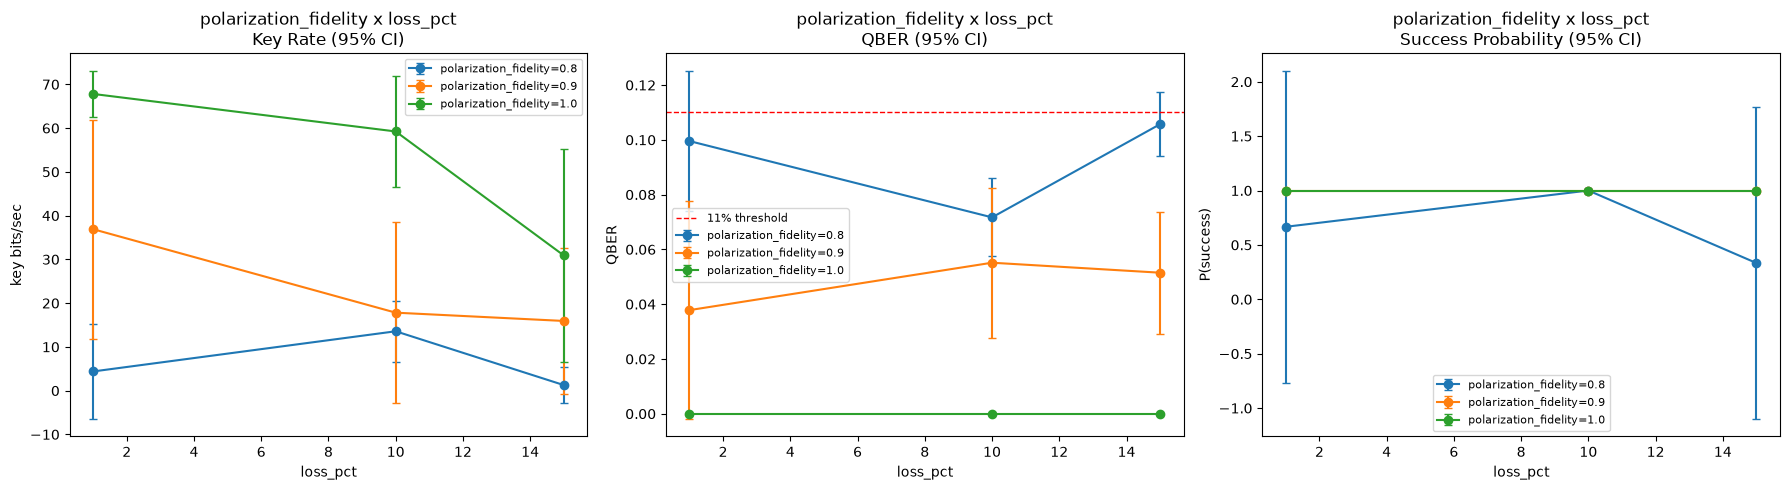

/tmp/ipykernel_82/1057834559.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)


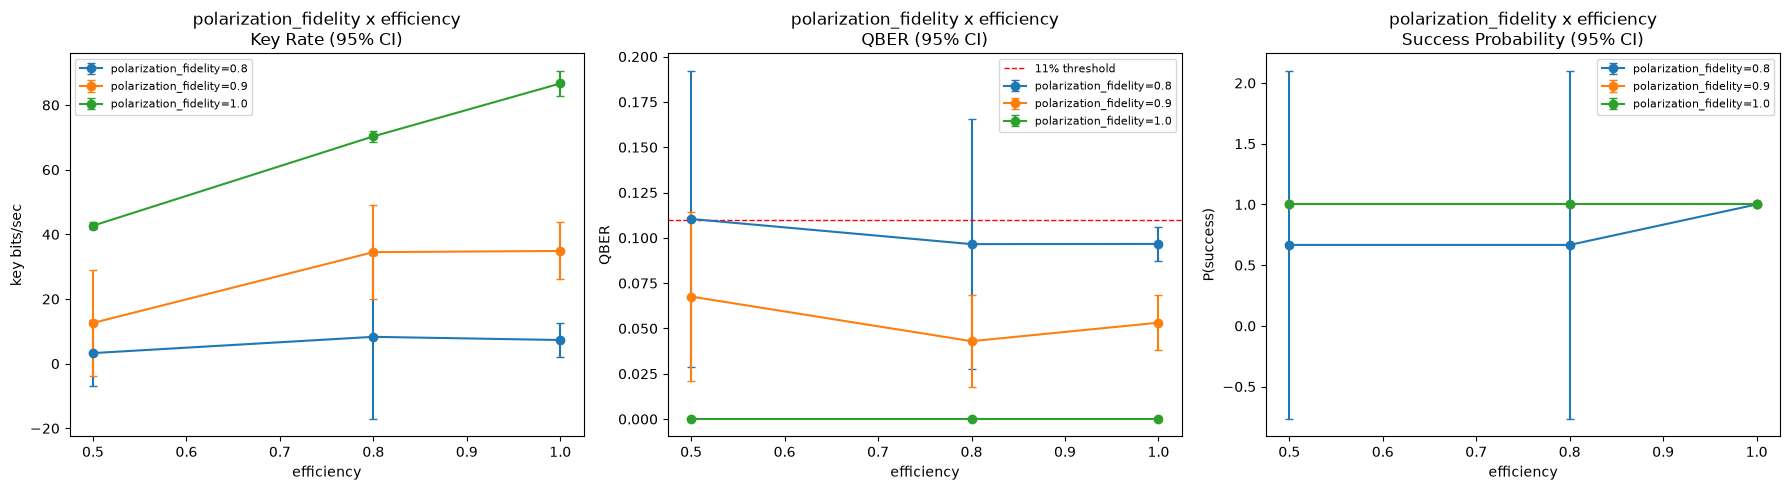

/tmp/ipykernel_82/1057834559.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)


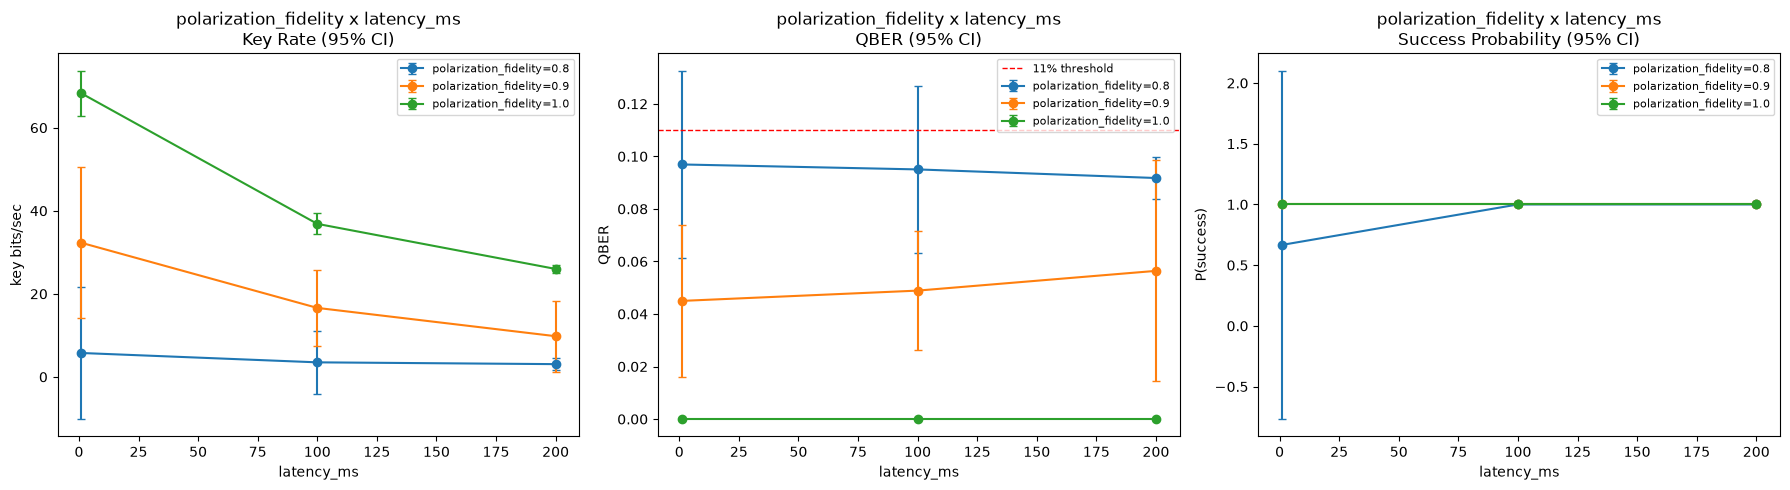

/tmp/ipykernel_82/1057834559.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)


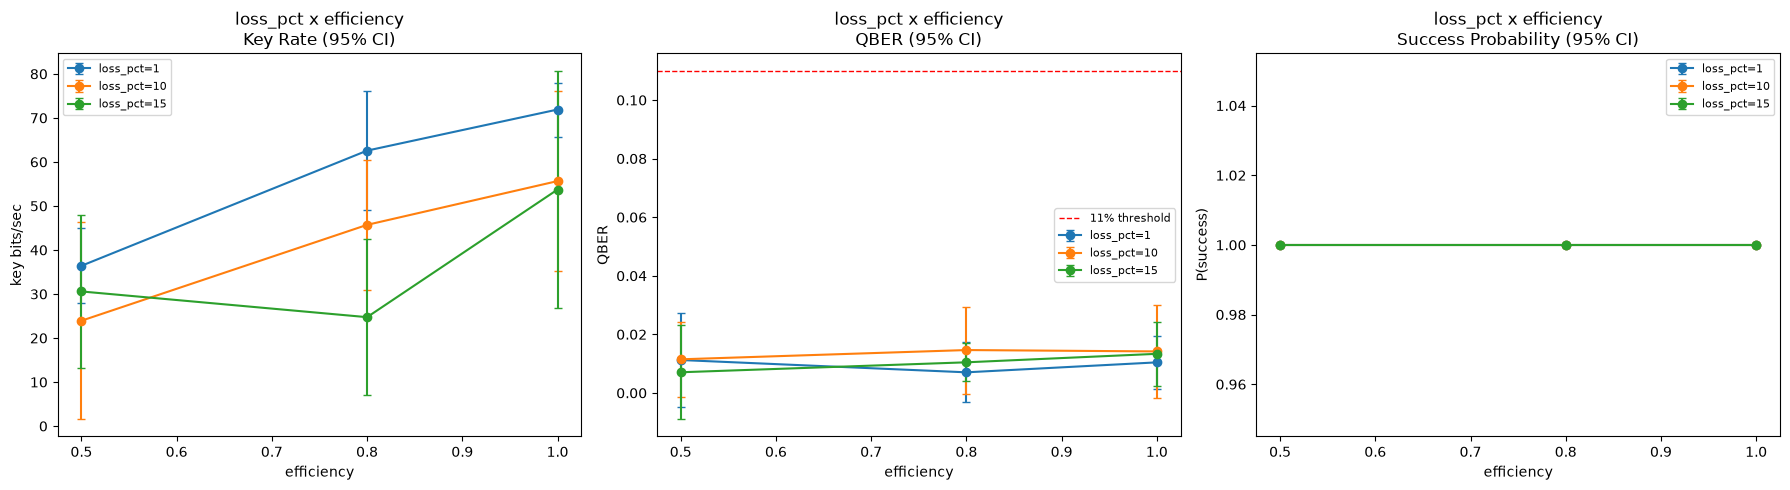

/tmp/ipykernel_82/1057834559.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  df['success'] = (df['qber'] < 0.11) & (df['key_bits_per_sec'] >= 1.0) & (~has_error)


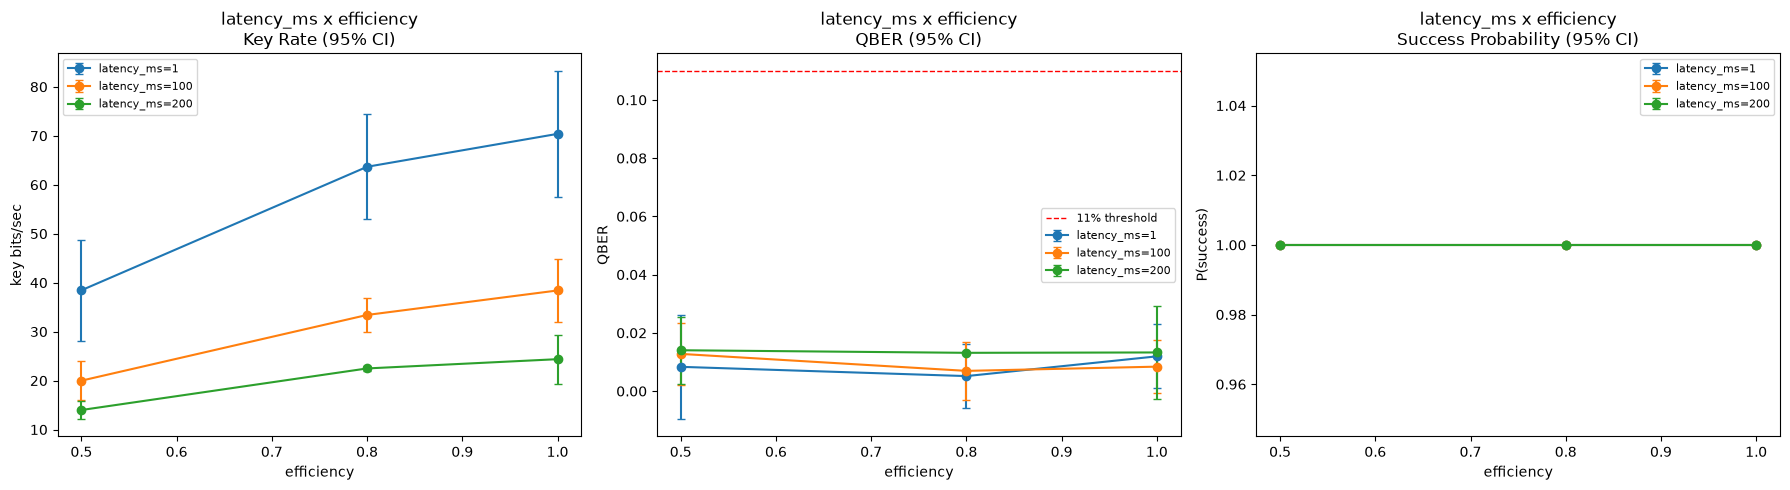

                sum_sq    df           F        PR(>F)
C(a)       9835.896940   2.0  118.812339  4.256254e-11
C(b)       1957.076752   2.0   23.640433  9.212539e-06
C(a):C(b)  1334.763378   4.0    8.061611  6.583712e-04
Residual    745.066320  18.0         NaN           NaN
                 sum_sq    df           F        PR(>F)
C(a)       16839.942609   2.0  345.203842  4.414720e-15
C(b)        2722.375955   2.0   55.806285  1.921447e-08
C(a):C(b)   1261.999552   4.0   12.934934  3.902346e-05
Residual     439.043443  18.0         NaN           NaN
                sum_sq    df           F        PR(>F)
C(a)       7172.289090   2.0  237.739265  1.142979e-13
C(b)       2439.497221   2.0   80.861810  1.013926e-09
C(a):C(b)  1266.727116   4.0   20.994049  1.399044e-06
Residual    271.518472  18.0         NaN           NaN
                sum_sq    df          F        PR(>F)
C(a)       2055.265917   2.0  20.581660  2.233468e-05
C(b)       4088.554351   2.0  40.943236  2.003976e-07
C(a):C(b

In [43]:
plot_joint_pair(joint_results['pf_x_loss'], 'polarization_fidelity', 'loss_pct',
                 save_path='/home/fabric/work/qkd-pqc-dependability/results/polarization_fidelity_x_loss_pct_plot.png')
plot_joint_pair(joint_results['pf_x_efficiency'], 'polarization_fidelity', 'efficiency',
                 save_path='/home/fabric/work/qkd-pqc-dependability/results/polarization_fidelity_x_efficiency_plot.png')
plot_joint_pair(joint_results['pf_x_latency'], 'polarization_fidelity', 'latency_ms',
                 save_path='/home/fabric/work/qkd-pqc-dependability/results/polarization_fidelity_x_latency_ms_plot.png')
plot_joint_pair(joint_results['loss_x_efficiency'], 'loss_pct','efficiency',
                 save_path='/home/fabric/work/qkd-pqc-dependability/results/loss_pct_x_efficiency_plot.png')
plot_joint_pair(joint_results['latency_x_efficiency'], 'latency_ms','efficiency',
                 save_path='/home/fabric/work/qkd-pqc-dependability/results/latency_ms_x_efficiency_plot.png')


import pandas as pd
df_pf_loss = pd.DataFrame(joint_results['pf_x_loss'])
pf_loss = two_way_anova(df_pf_loss, 'polarization_fidelity', 'loss_pct', y_col='key_bits_per_sec')
print(pf_loss['anova_table'])

df_pf_efficiency = pd.DataFrame(joint_results['pf_x_efficiency'])
pf_efficiency = two_way_anova(df_pf_efficiency, 'polarization_fidelity', 'efficiency', y_col='key_bits_per_sec')
print(pf_efficiency['anova_table'])

df_pf_latency = pd.DataFrame(joint_results['pf_x_latency'])
pf_latency = two_way_anova(df_pf_latency, 'polarization_fidelity', 'latency_ms', y_col='key_bits_per_sec')
print(pf_latency['anova_table'])

df_loss_efficiency = pd.DataFrame(joint_results['loss_x_efficiency'])
loss_efficiency = two_way_anova(df_loss_efficiency, 'loss_pct', 'efficiency', y_col='key_bits_per_sec')
print(loss_efficiency['anova_table'])

df_latency_efficiency = pd.DataFrame(joint_results['latency_x_efficiency'])
pf_latency = two_way_anova(df_latency_efficiency, 'latency_ms', 'efficiency', y_col='key_bits_per_sec')
print(pf_latency['anova_table'])

In [37]:
def joint_ols_regression(joint_rows, axis1, axis2, y_col='key_bits_per_sec'):
    """OLS regression with interaction term, treating both axes as continuous
    predictors (not categorical, unlike two_way_anova's C(a)*C(b)). Use this
    when you want a fitted slope/interaction coefficient rather than a
    factor-level ANOVA table — e.g. to report an actual interaction effect
    size for the paper.

    joint_rows: list of row dicts as returned by run_joint_axis_sweep.
    """
    import pandas as pd
    import statsmodels.formula.api as smf

    df = pd.DataFrame(joint_rows)
    df = df.rename(columns={axis1: 'x1', axis2: 'x2', y_col: 'y'})
    df = df.dropna(subset=['x1', 'x2', 'y'])

    model = smf.ols("y ~ x1 * x2", data=df).fit()
    print(f"=== {axis1} x {axis2} -> {y_col} ===")
    print(model.summary())
    return model

In [44]:
model_pf_eff = joint_ols_regression(joint_results['pf_x_efficiency'], 'polarization_fidelity', 'efficiency', y_col='key_bits_per_sec')
model_pf_loss = joint_ols_regression(joint_results['pf_x_loss'], 'polarization_fidelity', 'loss_pct', y_col='key_bits_per_sec')
model_pf_latency = joint_ols_regression(joint_results['pf_x_latency'], 'polarization_fidelity', 'latency_ms', y_col='key_bits_per_sec')
model_loss_eff = joint_ols_regression(joint_results['loss_x_efficiency'], 'loss_pct', 'efficiency', y_col='key_bits_per_sec')
model_latency_eff = joint_ols_regression(joint_results['latency_x_efficiency'], 'latency_ms', 'efficiency', y_col='key_bits_per_sec')


=== polarization_fidelity x efficiency -> key_bits_per_sec ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     140.8
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           6.12e-15
Time:                        20:07:07   Log-Likelihood:                -88.338
No. Observations:                  27   AIC:                             184.7
Df Residuals:                      23   BIC:                             189.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [45]:
def joint_quadratic_regression(joint_rows, axis1, axis2, y_col='key_bits_per_sec'):
    """Quadratic regression with both axes and their interaction, fitting:
    y = b0 + b1*x1 + b2*x2 + b3*x1^2 + b4*x2^2 + b5*x1*x2

    Use this instead of joint_ols_regression when a straight-line interaction
    model doesn't capture curvature in either axis (e.g. loss_pct's
    retransmission-cascade behavior is known to be nonlinear).
    """
    import pandas as pd
    import statsmodels.formula.api as smf

    df = pd.DataFrame(joint_rows)
    df = df.rename(columns={axis1: 'x1', axis2: 'x2', y_col: 'y'})
    df = df.dropna(subset=['x1', 'x2', 'y'])

    model = smf.ols(
        "y ~ x1 + x2 + I(x1**2) + I(x2**2) + x1:x2",
        data=df
    ).fit()

    print(f"=== {axis1} x {axis2} -> {y_col} (quadratic) ===")
    print(model.summary())
    return model

In [ ]:
model_loss_eff_rate = joint_quadratic_regression(joint_results['loss_x_efficiency'], 'loss_pct', 'efficiency', y_col='key_bits_per_sec')

In [47]:
def joint_centered_regression(joint_rows, axis1, axis2, y_col='qber'):
    """Linear regression with mean-centered predictors and interaction:
    y = b0 + b1*x1_c + b2*x2_c + b3*x1_c*x2_c
    where x1_c = x1 - mean(x1), x2_c = x2 - mean(x2).

    Centering makes b1's p-value test the effect of axis1 AT THE AVERAGE
    value of axis2 (and vice versa for b2), rather than at axis2=0 — which
    is meaningless for something like efficiency or polarization_fidelity
    where 0 is outside the physically sampled range.
    """
    import pandas as pd
    import statsmodels.formula.api as smf

    df = pd.DataFrame(joint_rows)
    df = df.rename(columns={axis1: 'x1', axis2: 'x2', y_col: 'y'})
    df = df.dropna(subset=['x1', 'x2', 'y'])

    x1_mean = df['x1'].mean()
    x2_mean = df['x2'].mean()
    df['x1_c'] = df['x1'] - x1_mean
    df['x2_c'] = df['x2'] - x2_mean

    model = smf.ols("y ~ x1_c + x2_c + x1_c:x2_c", data=df).fit()

    print(f"=== {axis1} (centered at {x1_mean:.4f}) x {axis2} (centered at {x2_mean:.4f}) -> {y_col} ===")
    print(model.summary())
    return model, x1_mean, x2_mean

In [48]:
model_pf_eff = joint_centered_regression(joint_results['pf_x_efficiency'], 'polarization_fidelity', 'efficiency', y_col='key_bits_per_sec')
model_pf_loss = joint_centered_regression(joint_results['pf_x_loss'], 'polarization_fidelity', 'loss_pct', y_col='key_bits_per_sec')
model_pf_latency = joint_centered_regression(joint_results['pf_x_latency'], 'polarization_fidelity', 'latency_ms', y_col='key_bits_per_sec')
model_loss_eff = joint_centered_regression(joint_results['loss_x_efficiency'], 'loss_pct', 'efficiency', y_col='key_bits_per_sec')
model_latency_eff = joint_centered_regression(joint_results['latency_x_efficiency'], 'latency_ms', 'efficiency', y_col='key_bits_per_sec')


=== polarization_fidelity (centered at 0.9000) x efficiency (centered at 0.7667) -> key_bits_per_sec ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     140.8
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           6.12e-15
Time:                        20:23:48   Log-Likelihood:                -88.338
No. Observations:                  27   AIC:                             184.7
Df Residuals:                      23   BIC:                             189.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [49]:
def combine_joint_results(results_dir, output_name="combined_joint_results"):
    """Combine every results/joint_*.json file into one JSON and one CSV.
    Excludes any file with 'BACKUP' in its name. Each row gets a
    'source_file' field so you can trace it back to which pair it came from.
    """
    import json
    import glob
    import pandas as pd
    from pathlib import Path

    results_dir = Path(results_dir)
    all_rows = []

    json_files = sorted(glob.glob(str(results_dir / "joint_*.json")))
    included = []
    skipped = []

    for f in json_files:
        fname = Path(f).name
        if "BACKUP" in fname:
            skipped.append(fname)
            continue
        if fname == f"{output_name}.json":
            skipped.append(fname)
            continue

        try:
            data = json.loads(Path(f).read_text())
        except Exception as e:
            print(f"  !! could not parse {fname}: {e} — skipping")
            skipped.append(fname)
            continue

        if not isinstance(data, list):
            print(f"  !! {fname} is not a list of rows — skipping")
            skipped.append(fname)
            continue

        for row in data:
            row = dict(row)
            row["source_file"] = fname
            all_rows.append(row)
        included.append(f"{fname} ({len(data)} rows)")

    print("Included:")
    for f in included:
        print(f"  {f}")
    print("Skipped:")
    for f in skipped:
        print(f"  {f}")
    print(f"\nTotal combined rows: {len(all_rows)}")

    out_json = results_dir / f"{output_name}.json"
    out_csv = results_dir / f"{output_name}.csv"

    out_json.write_text(json.dumps(all_rows, indent=2))

    df = pd.DataFrame(all_rows)
    df.to_csv(out_csv, index=False)

    print(f"\nSaved -> {out_json}")
    print(f"Saved -> {out_csv}")

    return df

In [50]:
df_joint_combined = combine_joint_results('/home/fabric/work/qkd-pqc-dependability/results')

Included:
  joint_latency_ms_x_efficiency.json (27 rows)
  joint_loss_pct_x_efficiency.json (27 rows)
  joint_polarization_fidelity_x_efficiency.json (27 rows)
  joint_polarization_fidelity_x_latency_ms.json (27 rows)
  joint_polarization_fidelity_x_loss_pct.json (27 rows)
Skipped:
  joint_loss_x_efficiency_BACKUP_1785347938.json
  joint_pf_x_latency_BACKUP_1785344251.json
  joint_pf_x_loss_BACKUP_1785300216.json
  joint_pf_x_loss_BACKUP_1785300255.json

Total combined rows: 135

Saved -> /home/fabric/work/qkd-pqc-dependability/results/combined_joint_results.json
Saved -> /home/fabric/work/qkd-pqc-dependability/results/combined_joint_results.csv


In [58]:
import numpy as np

def binary_entropy(qber):
    """Binary entropy function H(p)"""
    if qber <= 0 or qber >= 1:
        return 0
    return -qber * np.log2(qber) - (1 - qber) * np.log2(1 - qber)

def theoretical_r_secure(
    # quantum channel parameters
    attenuation_db_per_km=0.2,
    distance_km=10.0,
    polarization_fidelity=0.98,
    # detector parameters
    detector_efficiency=0.8,
    dark_count_rate_hz=10.0,
    # classical fault parameters
    delay_ms=0.0,
    loss_pct=0.0,
    # protocol parameters (fixed)
    num_photons=100000,
    send_rate_hz=1000000.0,
    # measured constants
    B_bytes=310406,
    MSS=1428,
    RTO=0.248,
    RTT_0=0.030,
    b=2
):
    """
    Theoretical secure key rate as function of fault parameters.
    Based on:
    - Gisin et al. (2002) eq. 32 for QBER
    - Shor-Preskill formula for secure key fraction
    - Padhye et al. (1998) for TCP throughput
    
    Returns R_secure in bits/sec.
    """
    # transmission probability
    t_link = 10 ** (-attenuation_db_per_km * distance_km / 10)
    
    # QBER from Gisin eq. 32 (with mu=1 for QFabric)
    optical_error = 1 - polarization_fidelity
    dark_count_prob = dark_count_rate_hz / send_rate_hz
    dark_count_qber = dark_count_prob / (t_link * detector_efficiency)
    qber = optical_error + dark_count_qber
    
    # secure key fraction from Shor-Preskill
    if qber >= 0.11:
        return 0.0
    secure_fraction = max(0.0, 1 - 2 * binary_entropy(qber))
    
    # sifted bits
    N_sift = 0.5 * detector_efficiency * t_link * num_photons
    
    # secure bits
    N_secure = N_sift * secure_fraction
    
    # TCP throughput from Padhye et al.
    p = loss_pct / 100.0
    RTT = RTT_0 + 2 * delay_ms / 1000.0
    N_packets = B_bytes / MSS
    
    if p <= 0:
        # no packet loss — throughput limited by RTT only
        # approximate as B/RTT (one round trip per message)
        throughput_packets_per_sec = 1.0 / RTT if RTT > 0 else float('inf')
    else:
        # Padhye formula
        term1 = RTT * np.sqrt(2 * b * p / 3)
        term2 = RTO * min(1, 3 * np.sqrt(3 * b * p / 8)) * p * (1 + 32 * p**2)
        throughput_packets_per_sec = 1.0 / (term1 + term2)
    
    # sifting time
    T = N_packets / throughput_packets_per_sec
    
    # secure key rate in bits/sec
    r_secure = N_secure / T
    
    return r_secure


# test against your experimental conditions
test_cases = [
    {'name': 'baseline',        'delay_ms': 0,   'loss_pct': 0},
    {'name': 'latency_100ms',   'delay_ms': 100, 'loss_pct': 0},
    {'name': 'loss_15pct',      'delay_ms': 0,   'loss_pct': 15},
    {'name': 'pf_0.8',          'delay_ms': 0,   'loss_pct': 0,  'polarization_fidelity': 0.8},
    {'name': 'joint_pf0.8_loss15', 'delay_ms': 0, 'loss_pct': 15, 'polarization_fidelity': 0.8},
]

print(f"{'Condition':<25} {'R_secure_theoretical':>20} {'units'}")
print("-" * 50)
for tc in test_cases:
    name = tc.pop('name')
    r = theoretical_r_secure(**tc)
    print(f"{name:<25} {r:>20.4f} bits/sec")

Condition                 R_secure_theoretical units
--------------------------------------------------
baseline                             2774.5546 bits/sec
latency_100ms                         361.8984 bits/sec
loss_15pct                           1075.4031 bits/sec
pf_0.8                                  0.0000 bits/sec
joint_pf0.8_loss15                      0.0000 bits/sec


In [59]:
def plot_theoretical_vs_actual(df_raw, axis_name, param_name, baseline_params=None, save_path=None):
    """Compare theoretical_r_secure predictions against actual measured key
    rate for one sweep axis. Holds all other parameters at baseline (their
    default in theoretical_r_secure, or overridden via baseline_params) and
    varies only param_name across the values actually swept in df_raw.

    axis_name: value in df_raw['axis'] column (e.g. 'loss_pct')
    param_name: matching keyword arg name in theoretical_r_secure
                (e.g. 'loss_pct', 'polarization_fidelity', 'distance_km')
    baseline_params: dict of overrides for the other theoretical_r_secure
                     args, if you don't want its hardcoded defaults.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy import stats

    baseline_params = baseline_params or {}

    d = df_raw[df_raw['axis'] == axis_name].sort_values('value')
    if d.empty:
        raise ValueError(f"No rows found for axis={axis_name}")

    # actual: mean + 95% CI per value, across repeated runs
    actual = d.groupby('value').agg(
        rate_mean=('key_bits_per_sec', 'mean'),
        rate_std=('key_bits_per_sec', 'std'),
        n=('key_bits_per_sec', 'size'),
    ).reset_index()

    def _ci_halfwidth(std, n):
        if n <= 1 or pd.isna(std):
            return 0.0
        t_crit = stats.t.ppf(0.975, n - 1)
        return t_crit * std / np.sqrt(n)

    actual['ci'] = actual.apply(lambda r: _ci_halfwidth(r['rate_std'], r['n']), axis=1)

    # theoretical: evaluate the model at each swept value, holding everything
    # else at baseline_params (or theoretical_r_secure's own defaults)
    theo_values = []
    for val in actual['value']:
        kwargs = {**baseline_params, param_name: val}
        result = theoretical_r_secure(**kwargs)
        # function is documented to return a single float, but its body has
        # a stray "return r_secure, using this..." comment artifact in your
        # paste — if it actually returns a tuple in your real file, unpack it:
        r_secure = result[0] if isinstance(result, tuple) else result
        theo_values.append(r_secure)
    actual['theoretical'] = theo_values

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(actual['value'], actual['rate_mean'], yerr=actual['ci'],
                marker='o', capsize=3, label='Actual (measured, 95% CI)', color='steelblue')
    ax.plot(actual['value'], actual['theoretical'], marker='s', linestyle='--',
            label='Theoretical (model)', color='darkorange')

    ax.set_title(f"Expected vs Actual Key Rate: {axis_name}")
    ax.set_xlabel(param_name)
    ax.set_ylabel('key bits/sec')
    ax.legend()

    if axis_name == 'dark_count_rate_hz':
        ax.set_xscale('log')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

    return actual

In [61]:
result_loss = plot_theoretical_vs_actual(df_baseline, 'loss_pct', 'loss_pct',
    save_path='/home/fabric/work/qkd-pqc-dependability/results/theo_vs_actual_loss.png')

result_pf = plot_theoretical_vs_actual(df_baseline, 'polarization_fidelity', 'polarization_fidelity',
    save_path='/home/fabric/work/qkd-pqc-dependability/results/theo_vs_actual_pf.png')

result_dc = plot_theoretical_vs_actual(df_baseline, 'dark_count_rate_hz', 'dark_count_rate_hz',
    save_path='/home/fabric/work/qkd-pqc-dependability/results/theo_vs_actual_dc.png')

NameError: name 'df_baseline' is not defined